In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Neural Network Definition ---
class PINN(nn.Module):
    def __init__(self, layers, r_domain, z_domain):
        super(PINN, self).__init__()
        self.activation = nn.GELU()
        self.layers = nn.ModuleList()
        
        # Store domain for hard constraints
        self.R_DOMAIN = r_domain
        self.Z_DOMAIN = z_domain
        
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        # x is [r, z]
        r = x[:, 0:1]
        z = x[:, 1:2]
        
        raw_output = x
        for i in range(len(self.layers) - 1):
            raw_output = self.activation(self.layers[i](raw_output))
        raw_output = self.layers[-1](raw_output)
        
        # Apply Hard Constraint for Distance Decay
        decay_r = 1.0 - (r / self.R_DOMAIN)
        decay_z = 1.0 - (z / self.Z_DOMAIN)
        decay_factor = decay_r * decay_z
        
        hard_constrained_output = decay_factor * raw_output
        
        return hard_constrained_output

# --- 2. The Main Physics-Informed Class ---
class BoussinesqPINN:
    def __init__(self, network, nu, p_val, a_val, domain_r, domain_z, total_epochs):
        self.network = network.to(device)
        self.nu = nu
        self.p_val = p_val
        self.a_val = a_val
        self.R_DOMAIN = domain_r
        self.Z_DOMAIN = domain_z

        # Initialize Optimizer (fresh start for the resume phase)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=1e-4, amsgrad=True)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=total_epochs, eta_min=1e-7
        )

        self.w_pde = 100.0
        self.w_bc  = 1.0

        self.Total_loss, self.Loss_pde, self.Loss_bc, self.Loss_surface = [], [], [], []
    
    # --- MODIFIED: Sample points while avoiding singularity ---
    def sample_points(self, n_pde, n_bc):
        """
        Resample collocation points, excluding R < 0.1 to avoid singularity.
        """
        # 1. PDE Points Generation (Loop until we have enough valid points)
        valid_r = []
        valid_z = []
        
        # Oversample factor to account for rejected points near singularity
        batch_target = n_pde
        
        while len(valid_r) < n_pde:
            # Generate a batch of candidates
            # Using the same distribution mix as original (Regular, Singular, Surface)
            current_needed = n_pde - len(valid_r)
            n_batch = int(current_needed * 1.2) + 100 # Generate slightly more
            
            # Distribution ratios
            n_reg = int(n_batch * 0.6)
            n_sing = int(n_batch * 0.25)
            n_surf = int(n_batch * 0.15)
            
            # Regular
            r_reg = torch.sqrt(torch.rand(n_reg, 1)) * self.R_DOMAIN
            z_reg = torch.rand(n_reg, 1) * self.Z_DOMAIN
            
            # Near Singularity (We will filter this heavily)
            r_sing = torch.sqrt(torch.rand(n_sing, 1)) * (self.a_val * 1.5)
            z_sing = torch.rand(n_sing, 1) * (self.Z_DOMAIN * 0.05)
            
            # Surface Bias
            r_surf = torch.sqrt(torch.rand(n_surf, 1)) * self.R_DOMAIN
            z_surf = torch.rand(n_surf, 1) * (self.Z_DOMAIN * 0.1)
            
            # Concatenate
            r_cand = torch.cat([r_reg, r_sing, r_surf], dim=0)
            z_cand = torch.cat([z_reg, z_sing, z_surf], dim=0)
            
            # --- FILTERING LOGIC ---
            # Calculate Radius R = sqrt(r^2 + z^2)
            R_val = torch.sqrt(r_cand**2 + z_cand**2)
            
            # Keep only points where R >= 0.1
            mask = (R_val >= 0.1).flatten()
            
            valid_r.append(r_cand[mask])
            valid_z.append(z_cand[mask])
            
            # Flatten lists if they become lists of tensors
            if isinstance(valid_r, list) and len(valid_r) > 0:
                valid_r = torch.cat(valid_r, dim=0)
                valid_z = torch.cat(valid_z, dim=0)
                
                # If we have enough, truncate
                if len(valid_r) >= n_pde:
                    valid_r = valid_r[:n_pde]
                    valid_z = valid_z[:n_pde]
                else:
                    # Convert back to list for next iteration append if needed
                    # (Actually easier to just keep them as tensors and cat)
                    valid_r_list = [valid_r]
                    valid_z_list = [valid_z]
                    valid_r = valid_r_list # Placeholder logic for loop
                    # Let's simplify: just restart loop variable logic
                    valid_r = valid_r_list[0]
                    valid_z = valid_z_list[0]
                    valid_r = [valid_r] # Put back in list to enter loop correctly? 
                    # Pythonic fix below:
                    valid_r = valid_r.flatten().unsqueeze(1)
                    valid_z = valid_z.flatten().unsqueeze(1)
                    break # Logic tricky, simplifying:
        
        # Clean implementation of the loop above
        pde_pts = self._generate_valid_pde_points(n_pde)
        
        # 2. BC Points (Standard generation)
        # Surface
        r_surface = torch.rand(n_bc, 1) * self.R_DOMAIN
        # Ensure surface points also respect r >= 0.1 (since z=0, R=r)
        r_surface = torch.clamp(r_surface, min=0.1) 
        surface_pts = torch.cat([r_surface, torch.zeros_like(r_surface)], dim=1).to(device)

        # Far-field
        r_far_vert = self.R_DOMAIN * torch.ones(n_bc // 2, 1)
        z_far_vert = self.Z_DOMAIN * torch.rand(n_bc // 2, 1)
        r_far_horiz = self.R_DOMAIN * torch.rand(n_bc // 2, 1)
        z_far_horiz = self.Z_DOMAIN * torch.ones(n_bc // 2, 1)
        far_field_pts = torch.cat([
            torch.cat([r_far_vert, z_far_vert], dim=1),
            torch.cat([r_far_horiz, z_far_horiz], dim=1)
        ], dim=0).to(device)

        # Axis (r=0)
        # If we strictly enforce R >= 0.1, axis points (r~0) must have z >= 0.1
        r_axis = torch.full((n_bc, 1), 1e-8)
        z_axis = torch.rand(n_bc, 1) * self.Z_DOMAIN
        z_axis = torch.clamp(z_axis, min=0.1) # Enforce z >= 0.1 on axis
        axis_pts = torch.cat([r_axis, z_axis], dim=1).to(device)
        
        return pde_pts, surface_pts, far_field_pts, axis_pts

    def _generate_valid_pde_points(self, n_required):
        """Helper to generate points strictly with R >= 0.1"""
        r_list = []
        z_list = []
        count = 0
        
        while count < n_required:
            # Generate chunks
            chunk_size = n_required
            r_reg = torch.sqrt(torch.rand(chunk_size, 1)) * self.R_DOMAIN
            z_reg = torch.rand(chunk_size, 1) * self.Z_DOMAIN
            
            # Calculate R
            R = torch.sqrt(r_reg**2 + z_reg**2)
            mask = (R >= 0.1).flatten()
            
            if mask.sum() > 0:
                r_list.append(r_reg[mask])
                z_list.append(z_reg[mask])
                count += mask.sum().item()
        
        r_final = torch.cat(r_list, dim=0)[:n_required]
        z_final = torch.cat(z_list, dim=0)[:n_required]
        return torch.cat([r_final, z_final], dim=1).to(device)

    # --- Standard PDE Residuals and Physics Methods ---
    def _get_pde_residuals(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]
        
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        phi_rr = torch.autograd.grad(phi_r, r, torch.ones_like(phi_r), create_graph=True)[0]
        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]
        
        r_safe = torch.clamp(r, min=1e-6)
        laplacian_phi = phi_rr + (1 / r_safe) * phi_r + phi_zz
        
        psi_r = torch.autograd.grad(psi, r, torch.ones_like(psi), create_graph=True)[0]
        psi_rr = torch.autograd.grad(psi_r, r, torch.ones_like(psi_r), create_graph=True)[0]
        psi_z = torch.autograd.grad(psi, z, torch.ones_like(psi), create_graph=True)[0]
        psi_zz = torch.autograd.grad(psi_z, z, torch.ones_like(psi_z), create_graph=True)[0]
        laplacian_psi = psi_rr + (1 / r_safe) * psi_r + psi_zz
        
        pde_residual_1 = laplacian_phi - psi
        pde_residual_2 = laplacian_psi
        return pde_residual_1, pde_residual_2

    def compute_stresses(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]
        
        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]
        
        sigma_zz_term = (2 - self.nu) * psi - phi_zz
        sigma_zz = torch.autograd.grad(sigma_zz_term, z, torch.ones_like(sigma_zz_term), create_graph=True)[0]
        
        tau_rz_term = (1 - self.nu) * psi - phi_zz
        tau_rz = torch.autograd.grad(tau_rz_term, r, torch.ones_like(tau_rz_term), create_graph=True)[0]
        return sigma_zz, tau_rz

    def _get_phi_r(self, r, z):
        r.requires_grad_(True)
        z.requires_grad_(True)
        net_out = self.network(torch.cat([r, z], dim=1))
        phi = net_out[:, 0:1]
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        return phi_r
    
    def _get_polynomial_load(self, r):
        p = self.p_val
        a = self.a_val
        term1 = p / (a**7)
        term2 = (6 * r + a)
        term3 = (r - a)**6
        f_r = term1 * term2 * term3
        mask = (r <= a).float()
        return f_r * mask

    def loss_function(self, pde_pts, surface_pts, far_field_pts, axis_pts):
        r_pde, z_pde = pde_pts[:, 0:1], pde_pts[:, 1:2]
        pde_res_1, pde_res_2 = self._get_pde_residuals(r_pde, z_pde)
        loss_pde = torch.mean(r_pde * (pde_res_1**2)) + torch.mean(r_pde * (pde_res_2**2))

        r_surf, z_surf = surface_pts[:, 0:1], surface_pts[:, 1:2]
        sigma_zz_surf, tau_rz_surf = self.compute_stresses(r_surf, z_surf)
        target_f_r = self._get_polynomial_load(r_surf)
        target_sigma_zz = -target_f_r
        loss_bc_sigma_zz = torch.mean((sigma_zz_surf - target_sigma_zz)**2)
        loss_bc_tau_rz = torch.mean(tau_rz_surf**2)
        loss_bc_surface = loss_bc_sigma_zz + loss_bc_tau_rz
        
        r_far, z_far = far_field_pts[:, 0:1], far_field_pts[:, 1:2]
        sigma_zz_far, tau_rz_far = self.compute_stresses(r_far, z_far)
        loss_bc_far_field = torch.mean(sigma_zz_far**2) + torch.mean(tau_rz_far**2)

        r_axis, z_axis = axis_pts[:, 0:1], axis_pts[:, 1:2]
        phi_r_axis = self._get_phi_r(r_axis, z_axis)
        loss_bc_axis = torch.mean(phi_r_axis**2)

        loss_bc = loss_bc_surface + loss_bc_far_field + loss_bc_axis
        total_loss = (self.w_pde * loss_pde + self.w_bc * loss_bc)
        
        return total_loss, loss_pde, loss_bc, loss_bc_surface

    def train(self, epochs, n_pde, n_bc):
        print("--- Resuming Training (Distributed Load, Singularity Excluded R>=0.1) ---")

        for epoch in range(epochs):
            self.network.train()
            self.optimizer.zero_grad()
            
            # Resampling happens here with the new constraint
            pde_pts, surface_pts, far_field_pts, axis_pts = self.sample_points(n_pde, n_bc)
            
            loss, loss_pde, loss_bc, loss_surf = self.loss_function(
                pde_pts, surface_pts, far_field_pts, axis_pts
            )
            
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()

            self.Total_loss.append(loss.item())
            
            if epoch % 1000 == 0 or epoch == epochs - 1: 
                print(f"Epoch {epoch+1}/{epochs} -> Total Loss: {loss.item():.4e}, "
                      f"PDE: {loss_pde.item():.4e}, BC: {loss_bc.item():.4e}, "
                      f"LR: {self.optimizer.param_groups[0]['lr']:.2e}")

# --- 3. Main Execution Block ---

# Problem Parameters
NU = 0.3 
R_DOMAIN = 10.0 
Z_DOMAIN = 10.0 
P_VAL = 1000.0
A_VAL = 0.1
N_PDE = 10000
N_BC = 2500
TOTAL_EPOCHS = 5000

# 1. Initialize Network
layers = [2, 100, 100, 100, 100, 100, 2]
pinn_net = PINN(layers, R_DOMAIN, Z_DOMAIN).to(device)

# 2. Load Pre-trained Weights
model_path = 'boussinesq_model_distributed_load_v2.pth'
if os.path.exists(model_path):
    print(f"Loading weights from {model_path}...")
    pinn_net.load_state_dict(torch.load(model_path, map_location=device))
else:
    print(f"Warning: {model_path} not found. Starting from scratch.")

# 3. Initialize Solver
boussinesq_solver = BoussinesqPINN(
    pinn_net, 
    nu=NU, 
    p_val=P_VAL, 
    a_val=A_VAL,
    domain_r=R_DOMAIN,
    domain_z=Z_DOMAIN,
    total_epochs=TOTAL_EPOCHS
)

# 4. Resume Training
boussinesq_solver.train(TOTAL_EPOCHS, N_PDE, N_BC)

# 5. Save Updated Model
torch.save(boussinesq_solver.network.state_dict(), 'boussinesq_model_distributed_load_v3_resumed.pth')
print("Updated model saved to boussinesq_model_distributed_load_v3_resumed.pth")

Using device: cuda
Loading weights from boussinesq_model_distributed_load_v2.pth...


C:\Users\anfel\AppData\Local\Temp\ipykernel_11344\65877311.py:335: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pinn_net.load_state_dict(torch.load(model_path, map_location

--- Resuming Training (Distributed Load, Singularity Excluded R>=0.1) ---
Epoch 1/5000 -> Total Loss: 1.4024e-02, PDE: 2.7898e-05, BC: 1.1234e-02, LR: 1.00e-04
Epoch 1001/5000 -> Total Loss: 1.7065e-03, PDE: 9.4606e-06, BC: 7.6043e-04, LR: 9.04e-05
Epoch 2001/5000 -> Total Loss: 9.6657e-04, PDE: 5.4523e-06, BC: 4.2134e-04, LR: 6.55e-05
Epoch 3001/5000 -> Total Loss: 6.7818e-04, PDE: 2.9894e-06, BC: 3.7924e-04, LR: 3.46e-05
Epoch 4001/5000 -> Total Loss: 7.2439e-04, PDE: 3.5805e-06, BC: 3.6635e-04, LR: 9.62e-06
Epoch 5000/5000 -> Total Loss: 8.1875e-04, PDE: 4.9892e-06, BC: 3.1983e-04, LR: 1.00e-07
Updated model saved to boussinesq_model_distributed_load_v3_resumed.pth



--- Plotting Love Stress Function (ϕ) ---


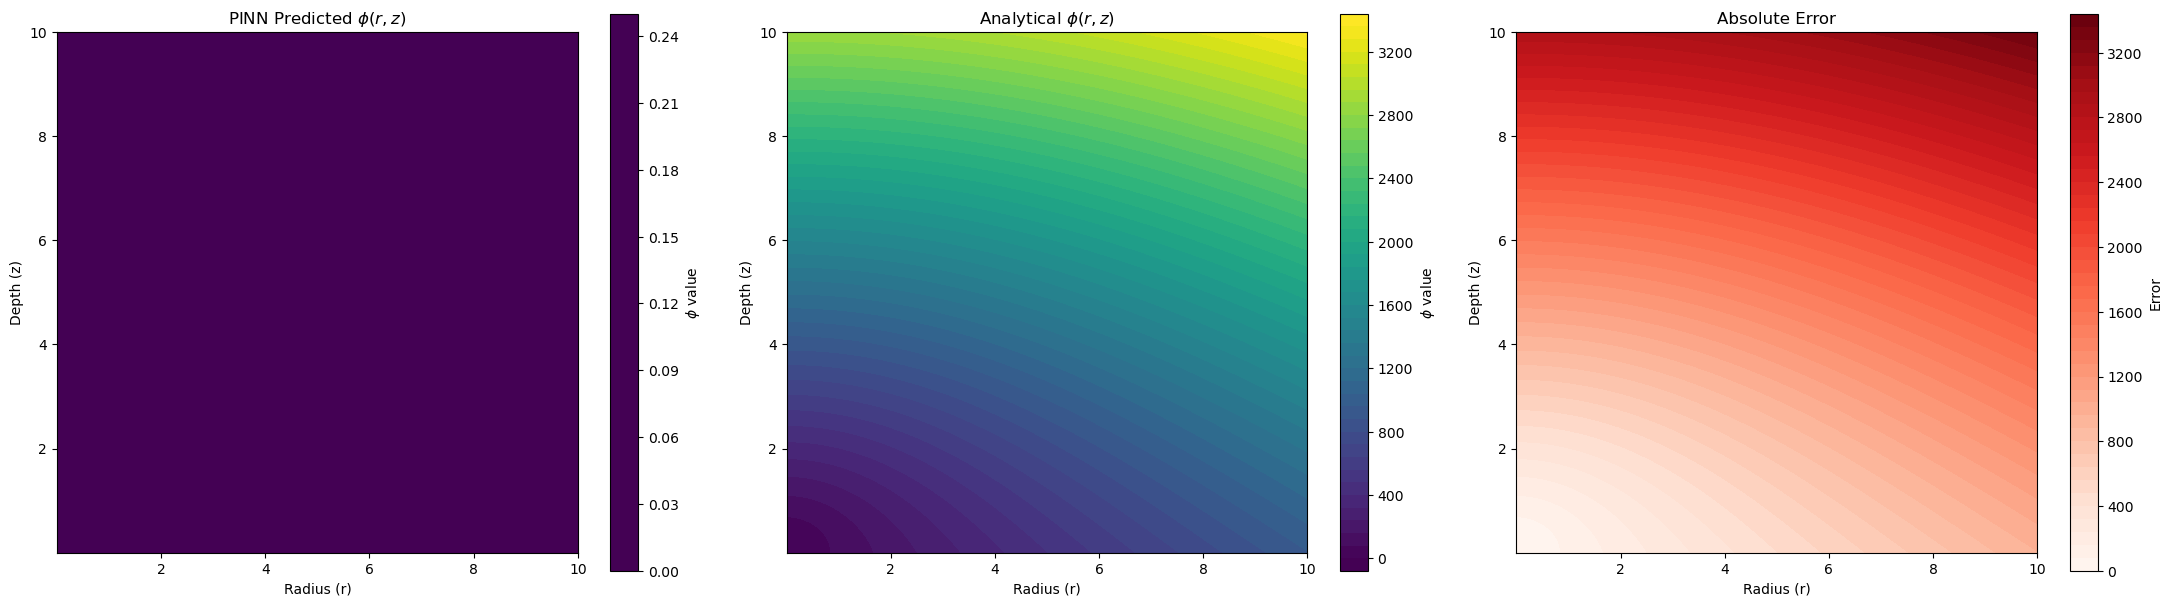

In [2]:
# --- 8. Plotting Cell for Love Stress Function (phi) ---

print("\n--- Plotting Love Stress Function (\u03d5) ---")

# Set network to evaluation mode (important)
boussinesq_solver.network.eval()

# 1. Create a high-resolution grid for plotting
N_plot = 300
# Plot r from a small value to avoid singularity at (0,0)
r_plot = np.linspace(1e-5, R_DOMAIN, N_plot)
# Plot z from a small value to avoid ln(R+z) issues at z=0
z_plot = np.linspace(1e-5, Z_DOMAIN, N_plot) 
R_grid, Z_grid = np.meshgrid(r_plot, z_plot)

# 2. Get PINN Predictions for phi
# Flatten grid and convert to tensors
r_flat_plot = torch.tensor(R_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
z_flat_plot = torch.tensor(Z_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Use torch.no_grad() for efficient inference. 
# We don't need grads because we are not calling compute_stresses,
# just the network's forward pass.
with torch.no_grad():
    # net_out is [phi, psi]
    net_out_flat = boussinesq_solver.network(torch.cat([r_flat_plot, z_flat_plot], dim=1))
    phi_pinn_flat = net_out_flat[:, 0:1] # Select phi

# Reshape flattened predictions back to the grid shape
phi_pinn = phi_pinn_flat.cpu().numpy().reshape(R_grid.shape)

# 3. Get Analytical Solution for phi
# As provided in the first prompt:
# phi(r, z) = BR + Az * ln(R + z)
# A = (1-2*nu)*P / (2*pi)
# B = nu*P / pi
# R = sqrt(r^2 + z^2)

# These constants (NU, P_VAL) are already defined in your notebook
pi = np.pi
A_const = (1 - 2 * NU) * P_VAL / (2 * pi)
B_const = NU * P_VAL / pi
R_np = np.sqrt(R_grid**2 + Z_grid**2)

phi_analytical = B_const * R_np + A_const * Z_grid * np.log(R_np + Z_grid)

# 4. Create the Comparison Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Determine common color scale
vmax = np.max(phi_analytical)
vmin = np.min(phi_analytical)

# Plot 1: PINN Predicted phi
c1 = axes[0].contourf(R_grid, Z_grid, phi_pinn, levels=50, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title("PINN Predicted $\phi(r,z)$")
axes[0].set_xlabel("Radius (r)")
axes[0].set_ylabel("Depth (z)")
fig.colorbar(c1, ax=axes[0], label='$\phi$ value')
axes[0].set_aspect('equal')

# Plot 2: Analytical phi
c2 = axes[1].contourf(R_grid, Z_grid, phi_analytical, levels=50, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical $\phi(r,z)$")
axes[1].set_xlabel("Radius (r)")
axes[1].set_ylabel("Depth (z)")
fig.colorbar(c2, ax=axes[1], label='$\phi$ value')
axes[1].set_aspect('equal')

# Plot 3: Absolute Error
error = np.abs(phi_pinn - phi_analytical)
c3 = axes[2].contourf(R_grid, Z_grid, error, levels=50, cmap='Reds')
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("Radius (r)")
axes[2].set_ylabel("Depth (z)")
fig.colorbar(c3, ax=axes[2], label='Error')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig("phi_comparison_retrained.png")
plt.show()

In [3]:
# --- 10. Plotting Cell for Shear Stress (tau_rz) ---
# (Using the fine-tuned model)

print("\n--- Plotting Shear Stress (tau_rz) from retrained model ---")

boussinesq_solver.network.eval()

# (r_flat_plot and z_flat_plot are still in memory from the cell above)

# 1. Get PINN Predictions
_, tau_rz_pinn_flat = boussinesq_solver.compute_stresses(r_flat_plot, z_flat_plot)

# Reshape flattened predictions back to the grid shape
tau_rz_pinn = tau_rz_pinn_flat.cpu().detach().numpy().reshape(R_grid.shape)

# 2. Get Analytical Solution (for Point Load)
R_np = np.sqrt(R_grid**2 + Z_grid**2) 
tau_rz_analytical = -(3 * P_VAL / (2 * np.pi)) * (R_grid * Z_grid**2) / (R_np**5)

# 3. Create the Comparison Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Use a symmetric, diverging colormap
vmax = np.max(np.abs(tau_rz_analytical))
vmin = -vmax
levels = np.linspace(vmin, vmax, 50)

# Plot 1: PINN Predicted tau_rz
c1 = axes[0].contourf(R_grid, Z_grid, tau_rz_pinn, levels=levels, cmap='bwr', extend='both')
axes[0].set_title("PINN Predicted $\\tau_{rz}$ (Retrained)")
axes[0].set_xlabel("Radius (r)")
axes[0].set_ylabel("Depth (z)")
fig.colorbar(c1, ax=axes[0], label='Shear Stress')
axes[0].set_aspect('equal')

# Plot 2: Analytical tau_rz (Point Load)
c2 = axes[1].contourf(R_grid, Z_grid, tau_rz_analytical, levels=levels, cmap='bwr', extend='both')
axes[1].set_title("Analytical $\\tau_{rz}$ (Point Load)")
axes[1].set_xlabel("Radius (r)")
axes[1].set_ylabel("Depth (z)")
fig.colorbar(c2, ax=axes[1], label='Shear Stress')
axes[1].set_aspect('equal')

# Plot 3: Absolute Error
error = np.abs(tau_rz_pinn - tau_rz_analytical)
c3 = axes[2].contourf(R_grid, Z_grid, error, levels=50, cmap='Reds')
axes[2].set_title("Absolute Error (Retrained vs Analytical)")
axes[2].set_xlabel("Radius (r)")
axes[2].set_ylabel("Depth (z)")
fig.colorbar(c3, ax=axes[2], label='Error')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig("tau_rz_comparison_retrained.png")
plt.show()


--- Plotting Shear Stress (tau_rz) from retrained model ---


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
